In [28]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from skimage.segmentation import slic
from skimage.measure import regionprops
from skimage.feature import graycomatrix, graycoprops
import sys

BASE_PATH = Path(r'D:\proyecto_eutrofizacion')  # ← ajusta esto

sys.path.insert(0, str(BASE_PATH / 'src'))

from water_masc1 import segmentar_agua, calcular_metricas, visualizar_mascara_final
from water_masc2 import conectar_graffiti_y_cerrar, suavizar_bordes_contorno

# Parámetros de segmentación ya calibrados
PARAMETROS = {
    'a_min': -120, 'a_max': 1,
    'b_min': -120,  'b_max': 14,
    'l_min': 50,   'l_max': 255,
    'h_min': 22,   'h_max': 180,
    's_min': 0,    's_max': 110,
}

In [29]:
def seleccionar_imagenes(df, anio, n_imagenes=None, salto=1):
    """
    Selecciona imágenes de un año específico.
    
    Parámetros:
    -----------
    df : DataFrame
        Índice de imágenes
    anio : int
        Año a filtrar
    n_imagenes : int (opcional)
        Número de imágenes a seleccionar
        - Si es None: toma todas las imágenes con el salto especificado
    salto : int
        Cada cuántas imágenes tomar (1=todas, 4=cada 4ta, etc)
        - salto=1: imagen 1, 2, 3, 4, 5...
        - salto=4: imagen 1, 5, 9, 13, 17...
    
    Retorna:
    --------
    DataFrame : imágenes seleccionadas
    """
    
    df_anio = df[df['group'].astype(str) == str(anio)].copy()
    df_anio = df_anio.reset_index(drop=True)
    
    # Selecciona cada salto-ésima imagen
    indices = range(0, len(df_anio), salto)
    df_con_salto = df_anio.iloc[list(indices)].reset_index(drop=True)
    
    # Si se especifica n_imagenes, toma solo las primeras
    if n_imagenes is not None:
        df_seleccion = df_con_salto.head(n_imagenes).reset_index(drop=True)
    else:
        df_seleccion = df_con_salto.reset_index(drop=True)
    
    print(f"Año {anio} — {len(df_anio)} imágenes disponibles")
    print(f"Salto: cada {salto} imágena")
    print(f"Seleccionadas: {len(df_seleccion)}")
    print(f"Índices originales: {list(df_seleccion.index[:10])}{'...' if len(df_seleccion) > 10 else ''}")
    
    return df_seleccion


# === PARÁMETROS A ELEGIR ===
ANIO_ELEGIDO = 2019
N_IMAGENES = 50          # ← None = toma todas con el salto; o especifica un número (ej: 20)
SALTO = 3                  # ← 1=todas, 4=cada 4ta, 2=cada 2da, etc

df_river = pd.read_csv(BASE_PATH / 'data/metadata/river_water_index.csv')
df_seleccion = seleccionar_imagenes(
    df_river, 
    anio=ANIO_ELEGIDO, 
    n_imagenes=N_IMAGENES,
    salto=SALTO
)

df_seleccion.head()

Año 2019 — 2025 imágenes disponibles
Salto: cada 3 imágena
Seleccionadas: 50
Índices originales: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


,filepath,source,group,has_gps,site,segmentation_mask_path,mask_type,mask_format
0,data/raw/external/river_water_dataset\2019\ima...,river_water_dataset,2019,True,basento_river,data/raw/external/river_water_dataset\2019\lab...,water_polygon_labelimg,polygon
1,data/raw/external/river_water_dataset\2019\ima...,river_water_dataset,2019,True,basento_river,data/raw/external/river_water_dataset\2019\lab...,water_polygon_labelimg,polygon
2,data/raw/external/river_water_dataset\2019\ima...,river_water_dataset,2019,True,basento_river,data/raw/external/river_water_dataset\2019\lab...,water_polygon_labelimg,polygon
3,data/raw/external/river_water_dataset\2019\ima...,river_water_dataset,2019,True,basento_river,data/raw/external/river_water_dataset\2019\lab...,water_polygon_labelimg,polygon
4,data/raw/external/river_water_dataset\2019\ima...,river_water_dataset,2019,True,basento_river,data/raw/external/river_water_dataset\2019\lab...,water_polygon_labelimg,polygon


In [30]:
from water_masc1 import cargar_mascara_desde_labeling

def extraer_caracteristicas_superpixeles(imagen, mascara_agua, n_segments=20):
    """
    Divide la región de agua en superpíxeles (SLIC) y calcula características
    de color y textura para cada uno.
    
    Parámetros:
    -----------
    imagen : np.ndarray (BGR)
    mascara_agua : np.ndarray (255=agua, 0=no-agua)
    n_segments : int
        Número aproximado de superpíxeles a generar sobre TODA la imagen
        (los que caigan fuera del agua se descartan después)
    
    Retorna:
    --------
    list[dict] : una fila por superpíxel con sus características
    """

    downscale = 4

    if downscale > 1:
        h, w = imagen.shape[:2]
        imagen = cv2.resize(imagen, (w//downscale, h//downscale))
        mascara_agua = cv2.resize(mascara_agua, (w//downscale, h//downscale))
    else:
        imagen = imagen
        mascara_agua = mascara_agua
        
    
    img_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(imagen, cv2.COLOR_BGR2Lab)
    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    # SLIC sobre la imagen completa (RGB), luego filtramos por máscara de agua
    segments = slic(
        img_rgb,
        n_segments=n_segments,
        compactness=20,
        sigma=1,
        mask=(mascara_agua > 0)   # SLIC solo genera superpíxeles dentro del agua
    )
    
    filas = []
    
    for label in np.unique(segments):
        if label == 0:
            continue  # 0 = fondo (fuera de la máscara)
        
        region_mask = (segments == label)
        area = region_mask.sum()
        
        if area < 15:  # descarta superpíxeles minúsculos (ruido de borde)
            continue
        
        # --- Color promedio y variabilidad ---
        h_vals = hsv[:,:,0][region_mask]
        s_vals = hsv[:,:,1][region_mask]
        v_vals = hsv[:,:,2][region_mask]
        l_vals = lab[:,:,0][region_mask]
        a_vals = lab[:,:,1][region_mask].astype(np.float32) - 128
        b_vals = lab[:,:,2][region_mask].astype(np.float32) - 128
        
        # --- Textura simple (desviación estándar de gris = proxy de turbidez/rugosidad) ---
        gray_vals = gray[region_mask]
        textura_std = gray_vals.std()
        
        # --- Centroide (para ubicar la anomalía después en la imagen) ---
        ys, xs = np.where(region_mask)
        centroid_x = xs.mean()
        centroid_y = ys.mean()
        
        filas.append({
            'h_mean': h_vals.mean(), 'h_std': h_vals.std(),
            's_mean': s_vals.mean(), 's_std': s_vals.std(),
            'v_mean': v_vals.mean(), 'v_std': v_vals.std(),
            'l_mean': l_vals.mean(),
            'a_mean': a_vals.mean(),
            'b_mean': b_vals.mean(),
            'textura_std': textura_std,
            'area_px': int(area),
            'centroid_x': float(centroid_x),
            'centroid_y': float(centroid_y),
            'superpixel_label': int(label),
        })
    
    return filas


def construir_tabla_superpixeles(df_seleccion, base_path, parametros, n_segments=250):
    """
    - Segmenta agua en cada imagen
    - Extrae superpíxeles y características
    - Etiqueta cada superpíxel con su foto de origen
    - Devuelve una sola tabla con todo
    """

    todas_las_filas = []
    errores = []

    for idx, row in df_seleccion.iterrows():
        
        ruta_imagen = Path(base_path) / row['filepath']
        nombre_foto = Path(row['filepath']).name
        
        print(f"[{idx+1}/{len(df_seleccion)}] Procesando {nombre_foto}...")
        
        imagen = cv2.imread(str(ruta_imagen))
        if imagen is None:
            errores.append(nombre_foto)
            continue

        # --- Segmentación ---
        mascara_pred = segmentar_agua(imagen, **parametros, downscale=4, verbose=False)
        mascara_final = conectar_graffiti_y_cerrar(mascara_pred, skeleton_kernel=3, dilation_kernel=30)
        mascara_final = suavizar_bordes_contorno(mascara_final, contour_approx=7)

        # Cargar máscara desde labels_segmentation
        #ruta_mascara = Path(base_path) / row['segmentation_mask_path']
        #alto, ancho = imagen.shape[:2]
        #mascara_final = cargar_mascara_desde_labeling(str(ruta_mascara), alto, ancho)
        
        if (mascara_final > 0).sum() < 500:
            print(f"  ⚠ Máscara de agua muy pequeña o vacía, se omite")
            continue
        
        # --- Superpíxeles + características (Etapas 2-3) ---
        filas_imagen = extraer_caracteristicas_superpixeles(
            imagen, mascara_final, n_segments=n_segments
        )

        # --- Etiqueta cada fila con su foto de origen (PASO 3) ---
        for fila in filas_imagen:
            fila['foto_origen'] = nombre_foto
            fila['anio'] = row['group']
        
        todas_las_filas.extend(filas_imagen)
        print(f"  ✓ {len(filas_imagen)} superpíxeles extraídos")

    df_tabla = pd.DataFrame(todas_las_filas)

    # ID único de superpíxel dentro de la tabla completa
    df_tabla.insert(0, 'superpixel_id', range(1, len(df_tabla) + 1))

    print(f"\n{'='*60}")
    print(f"Tabla final: {len(df_tabla)} superpíxeles de {df_seleccion.shape[0] - len(errores)} imágenes")
    if errores:
        print(f"Imágenes con error: {errores}")
    print(f"{'='*60}")

    return df_tabla

In [31]:
# Ejecuta el pipeline
import matplotlib.pyplot as plt

df_superpixeles = construir_tabla_superpixeles(
    df_seleccion,
    base_path=BASE_PATH,
    parametros=PARAMETROS,
    n_segments=20
)

df_superpixeles.head(10)

[1/50] Procesando DJI_11.JPG...
  ✓ 19 superpíxeles extraídos
[2/50] Procesando DJI_14.JPG...
  ✓ 20 superpíxeles extraídos
[3/50] Procesando DJI_17.JPG...
  ✓ 19 superpíxeles extraídos
[4/50] Procesando DJI_20.JPG...
  ✓ 18 superpíxeles extraídos
[5/50] Procesando DJI_23.JPG...
  ✓ 20 superpíxeles extraídos
[6/50] Procesando DJI_26.JPG...
  ✓ 20 superpíxeles extraídos
[7/50] Procesando DJI_29.JPG...
  ✓ 20 superpíxeles extraídos
[8/50] Procesando DJI_38.JPG...
  ✓ 20 superpíxeles extraídos
[9/50] Procesando DJI_41.JPG...
  ✓ 20 superpíxeles extraídos
[10/50] Procesando DJI_44.JPG...
  ✓ 19 superpíxeles extraídos
[11/50] Procesando DJI_47.JPG...
  ✓ 20 superpíxeles extraídos
[12/50] Procesando DJI_50.JPG...
  ✓ 20 superpíxeles extraídos
[13/50] Procesando DJI_78.JPG...
  ✓ 20 superpíxeles extraídos
[14/50] Procesando DJI_81.JPG...
  ✓ 20 superpíxeles extraídos
[15/50] Procesando DJI_84.JPG...
  ✓ 19 superpíxeles extraídos
[16/50] Procesando DJI_87.JPG...
  ✓ 20 superpíxeles extraídos
[

,superpixel_id,h_mean,h_std,s_mean,s_std,v_mean,v_std,l_mean,a_mean,b_mean,textura_std,area_px,centroid_x,centroid_y,superpixel_label,foto_origen,anio
0,1,95.989996,3.283884,44.566136,9.720700,148.541867,15.136639,148.231197,-6.150611,-5.159874,15.247869,5398,43.642275,28.804557,1,DJI_11.JPG,2019
1,2,96.337287,2.331049,38.678025,7.007748,158.763640,15.925445,158.626483,-5.506146,-4.818633,15.992445,4637,144.935734,21.375027,2,DJI_11.JPG,2019
2,3,96.988469,3.312561,42.729029,7.775409,155.524359,19.844257,154.215624,-5.515999,-5.471894,19.531968,3469,257.084174,14.652926,3,DJI_11.JPG,2019
3,4,94.730599,3.189215,34.055086,6.254792,158.163249,15.985439,159.527543,-5.351428,-3.854443,15.509472,2487,377.165661,10.429433,4,DJI_11.JPG,2019
4,5,91.975945,3.198116,32.061856,5.713939,149.256443,14.319980,152.747423,-5.799828,-2.689862,14.024989,2328,484.272766,10.868986,5,DJI_11.JPG,2019
5,6,90.033098,4.549062,32.364519,6.713560,142.845984,12.751776,147.000441,-6.016328,-2.097970,12.593944,2266,585.238747,12.710062,6,DJI_11.JPG,2019
6,7,88.251864,4.272456,32.095278,5.977106,140.394366,11.159285,144.954018,-6.239022,-1.529412,11.090921,2414,660.350456,17.056752,7,DJI_11.JPG,2019
7,8,81.826642,9.134341,30.294118,6.135392,137.154684,6.327068,142.244631,-6.452225,0.061002,6.460726,3213,736.821040,20.694055,8,DJI_11.JPG,2019
8,9,75.230256,8.989613,26.596923,5.350350,138.974872,3.976841,144.317436,-6.370256,1.562564,4.422379,1950,787.684103,27.837949,9,DJI_11.JPG,2019
9,10,73.108860,5.569451,24.438737,5.223674,141.780396,5.061994,147.159284,-6.362394,2.192743,5.448637,2122,833.248351,20.322809,10,DJI_11.JPG,2019


In [32]:
OUTPUT_DIR = BASE_PATH / 'data' / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

nombre_archivo = f"superpixeles_anio{ANIO_ELEGIDO}_n{N_IMAGENES}.csv"
ruta_salida = OUTPUT_DIR / nombre_archivo

df_superpixeles.to_csv(ruta_salida, index=False)

print(f"✓ Tabla guardada en: {ruta_salida}")
print(f"  Filas: {len(df_superpixeles)}")
print(f"  Columnas: {list(df_superpixeles.columns)}")

✓ Tabla guardada en: D:\proyecto_eutrofizacion\data\processed\superpixeles_anio2019_n50.csv
  Filas: 962
  Columnas: ['superpixel_id', 'h_mean', 'h_std', 's_mean', 's_std', 'v_mean', 'v_std', 'l_mean', 'a_mean', 'b_mean', 'textura_std', 'area_px', 'centroid_x', 'centroid_y', 'superpixel_label', 'foto_origen', 'anio']


# Cargar y trabajar con tabla creada de superpíxeles

In [33]:
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import seaborn as sns

CARACTERISTICAS_DETECCION = [
    'h_mean', 'h_std',          # Tono y variabilidad
    's_mean', 's_std',          # Saturación y variabilidad
    'v_mean', 'v_std',          # Brillo y variabilidad
    'l_mean',                   # Luminancia Lab
    'a_mean',                   # Eje verde-rojo
    'b_mean',                   # Eje azul-amarillo
    'textura_std',              # Turbidez/rugosidad
]

X = df_superpixeles[CARACTERISTICAS_DETECCION].copy()

print(f"Features para detección: {len(CARACTERISTICAS_DETECCION)}")
print(f"Superpíxeles: {len(X)}")
print(f"\nEstadísticas de features:")
print(X.describe())

Features para detección: 10
Superpíxeles: 962

Estadísticas de features:
           h_mean       h_std      s_mean       s_std      v_mean       v_std  \
count  962.000000  962.000000  962.000000  962.000000  962.000000  962.000000   
mean    64.892200   10.588695   21.177072    5.896650  144.209755    9.062823   
std     26.451573    7.411771   11.100832    3.620627   25.555139    6.089747   
min     24.020269    0.000000    3.588785    0.790429   94.805508    0.940690   
25%     39.503462    4.045257   12.977254    3.222634  123.848807    4.386524   
50%     63.115722    8.615770   18.125016    5.058307  143.641710    7.637379   
75%     89.828015   15.802782   28.598136    7.828917  161.355280   12.130069   
max    112.435666   36.717953   65.692308   21.793010  207.351852   37.795023   

           l_mean      a_mean      b_mean  textura_std  
count  962.000000  962.000000  962.000000   962.000000  
mean   149.465795   -2.906096    1.790831     9.245597  
std     25.175161    1.850

## Isolation Forest

In [35]:
# Normaliza las características (importante para Isolation Forest)
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

# Entrena Isolation Forest
# contamination = porcentaje esperado de anomalías (ajusta según necesidad)
iso_forest = IsolationForest(
    contamination=0.1,
    random_state=42,
    n_estimators=100
)

# Predice: -1 = anomalía, 1 = normal
predicciones = iso_forest.fit_predict(X_escalado)

# Score de anomalía: más negativo = más anómalo
scores_anomalia = iso_forest.score_samples(X_escalado)

# Añade los resultados a la tabla
df_superpixeles['anomalia'] = predicciones  # -1 o 1
df_superpixeles['score_anomalia'] = scores_anomalia  # valores negativos = más raro

# Ordena por anomalía (más raro primero)
df_superpixeles_ordenado = df_superpixeles.sort_values('score_anomalia', ascending=True)

print(f"Anomalías detectadas: {(df_superpixeles['anomalia'] == -1).sum()}")
print(f"Normal: {(df_superpixeles['anomalia'] == 1).sum()}")

Anomalías detectadas: 97
Normal: 865


In [36]:
# TOP 10 superpíxeles más anómalos
print("TOP 10 SUPERPÍXELES MÁS ANÓMALOS:")
print("="*80)

top_anomalas = df_superpixeles_ordenado.head(10)

for idx, row in top_anomalas.iterrows():
    print(f"\nSuperpíxel ID: {row['superpixel_id']}")
    print(f"  Foto origen: {row['foto_origen']}")
    print(f"  Score anomalía: {row['score_anomalia']:.4f}")
    print(f"  Posición en foto: ({row['centroid_x']:.0f}, {row['centroid_y']:.0f})")
    print(f"  Color Lab: L={row['l_mean']:.1f}, a*={row['a_mean']:.1f}, b*={row['b_mean']:.1f}")
    print(f"  Saturación: {row['s_mean']:.1f}")
    print(f"  Textura (turbidez): {row['textura_std']:.2f}")

TOP 10 SUPERPÍXELES MÁS ANÓMALOS:

Superpíxel ID: 618
  Foto origen: DJI_193.JPG
  Score anomalía: -0.6719
  Posición en foto: (1241, 592)
  Color Lab: L=128.4, a*=-10.4, b*=3.3
  Saturación: 50.9
  Textura (turbidez): 37.17

Superpíxel ID: 395
  Foto origen: DJI_124.JPG
  Score anomalía: -0.6407
  Posición en foto: (578, 325)
  Color Lab: L=111.2, a*=-1.3, b*=-1.3
  Saturación: 30.4
  Textura (turbidez): 29.16

Superpíxel ID: 621
  Foto origen: DJI_193.JPG
  Score anomalía: -0.6326
  Posición en foto: (1247, 592)
  Color Lab: L=108.0, a*=-6.1, b*=-3.9
  Saturación: 56.9
  Textura (turbidez): 23.91

Superpíxel ID: 463
  Foto origen: DJI_145.JPG
  Score anomalía: -0.6153
  Posición en foto: (1040, 495)
  Color Lab: L=156.3, a*=-2.2, b*=-2.2
  Saturación: 24.5
  Textura (turbidez): 32.40

Superpíxel ID: 613
  Foto origen: DJI_193.JPG
  Score anomalía: -0.6132
  Posición en foto: (1243, 588)
  Color Lab: L=113.0, a*=-9.4, b*=-0.2
  Saturación: 55.2
  Textura (turbidez): 25.33

Superpíxel 

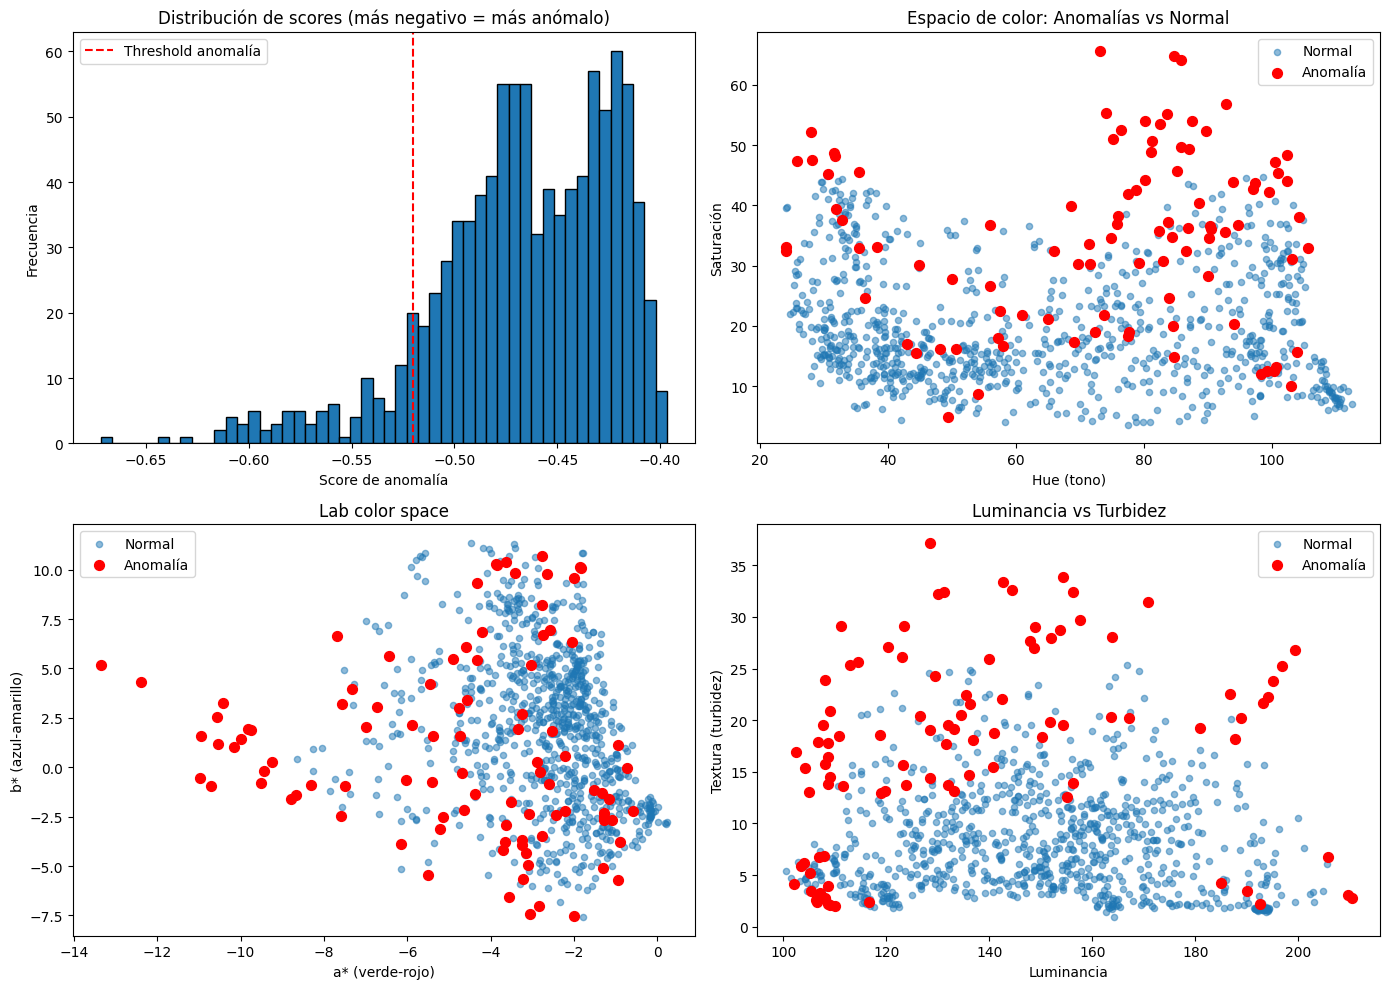

In [37]:
# Gráfico 1: Distribución de scores de anomalía
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Score de anomalía
axes[0, 0].hist(df_superpixeles['score_anomalia'], bins=50, edgecolor='black')
axes[0, 0].axvline(df_superpixeles[df_superpixeles['anomalia'] == -1]['score_anomalia'].max(), 
                   color='red', linestyle='--', label='Threshold anomalía')
axes[0, 0].set_xlabel('Score de anomalía')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de scores (más negativo = más anómalo)')
axes[0, 0].legend()

# Saturación: anomalías vs normal
axes[0, 1].scatter(df_superpixeles[df_superpixeles['anomalia'] == 1]['h_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == 1]['s_mean'],
                   alpha=0.5, label='Normal', s=20)
axes[0, 1].scatter(df_superpixeles[df_superpixeles['anomalia'] == -1]['h_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == -1]['s_mean'],
                   color='red', label='Anomalía', s=50)
axes[0, 1].set_xlabel('Hue (tono)')
axes[0, 1].set_ylabel('Saturación')
axes[0, 1].set_title('Espacio de color: Anomalías vs Normal')
axes[0, 1].legend()

# Lab a* vs b*
axes[1, 0].scatter(df_superpixeles[df_superpixeles['anomalia'] == 1]['a_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == 1]['b_mean'],
                   alpha=0.5, label='Normal', s=20)
axes[1, 0].scatter(df_superpixeles[df_superpixeles['anomalia'] == -1]['a_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == -1]['b_mean'],
                   color='red', label='Anomalía', s=50)
axes[1, 0].set_xlabel('a* (verde-rojo)')
axes[1, 0].set_ylabel('b* (azul-amarillo)')
axes[1, 0].set_title('Lab color space')
axes[1, 0].legend()

# Textura vs Luminancia
axes[1, 1].scatter(df_superpixeles[df_superpixeles['anomalia'] == 1]['l_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == 1]['textura_std'],
                   alpha=0.5, label='Normal', s=20)
axes[1, 1].scatter(df_superpixeles[df_superpixeles['anomalia'] == -1]['l_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == -1]['textura_std'],
                   color='red', label='Anomalía', s=50)
axes[1, 1].set_xlabel('Luminancia')
axes[1, 1].set_ylabel('Textura (turbidez)')
axes[1, 1].set_title('Luminancia vs Turbidez')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## z_score

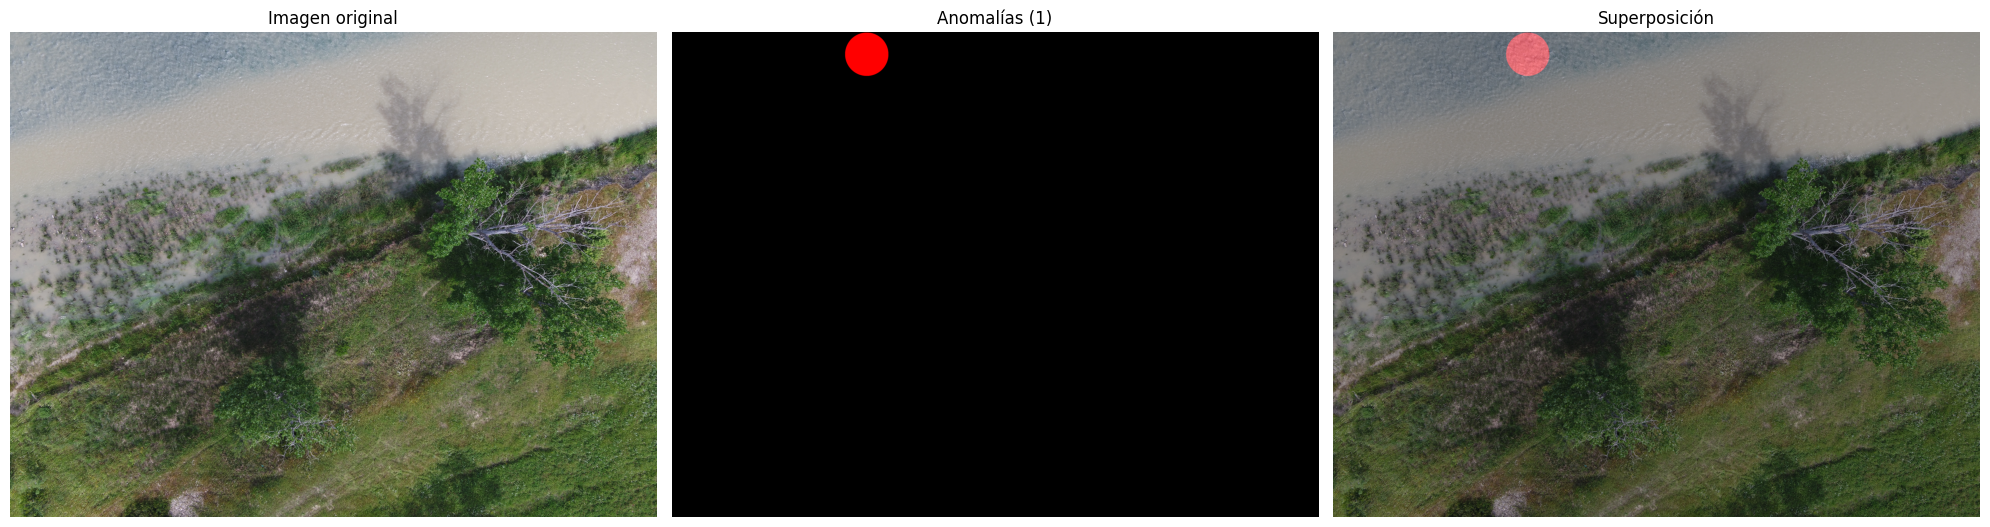


DJI_41.JPG: 1 anomalías


In [76]:
df_anomalias = df_superpixeles[df_superpixeles['anomalia'] == -1].copy()


def visualizar_anomalias_en_imagen(
    ruta_imagen, 
    df_superpixeles_anomalias,
    foto_origen,
    downscale=2  # ← mismo que usaste en entrenamiento
):
    """
    Visualiza anomalías escalando correctamente los centroides.
    """
    
    imagen = cv2.imread(str(ruta_imagen))
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    h, w = imagen_rgb.shape[:2]
    
    df_imagen = df_superpixeles_anomalias[
        df_superpixeles_anomalias['foto_origen'] == foto_origen
    ]
    
    anomalias = df_imagen[df_imagen['anomalia'] == -1]
    
    if len(anomalias) == 0:
        print(f"Sin anomalías en {foto_origen}")
        return
    
    mascara_anomalias = np.zeros((h, w, 3), dtype=np.uint8)
    
    for idx, row in anomalias.iterrows():
        # Escala los centroides si fueron generados en imagen downscaleada
        centroid_x = int(row['centroid_x'] * downscale)  # ← ESCALA
        centroid_y = int(row['centroid_y'] * downscale)  # ← ESCALA
        
        # Asegúrate que está dentro de imagen
        centroid_x = min(max(centroid_x, 0), w - 1)
        centroid_y = min(max(centroid_y, 0), h - 1)
        
        area = int(row['area_px'] * downscale * downscale)  # ← ESCALA
        radio = max(8, int(np.sqrt(area / np.pi)))
        
        cv2.circle(mascara_anomalias, (centroid_x, centroid_y), radio, (255, 0, 0), -1)
    
    imagen_resultado = cv2.addWeighted(imagen_rgb, 0.75, mascara_anomalias, 0.5, 0)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    
    axes[0].imshow(imagen_rgb)
    axes[0].set_title('Imagen original')
    axes[0].axis('off')
    
    axes[1].imshow(mascara_anomalias)
    axes[1].set_title(f'Anomalías ({len(anomalias)})')
    axes[1].axis('off')
    
    axes[2].imshow(imagen_resultado)
    axes[2].set_title('Superposición')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{foto_origen}: {len(anomalias)} anomalías")


# === USO ===
INDICE_FOTO = 7
DOWNSCALE = 4  # ← MISMO que usaste en extraer_caracteristicas_superpixeles

df_index = pd.read_csv(BASE_PATH / 'data' / 'metadata' / 'river_water_index.csv')

foto_a_visualizar = df_anomalias['foto_origen'].unique()[INDICE_FOTO]
row_imagen = df_index[df_index['filepath'].str.contains(foto_a_visualizar)].iloc[0]
ruta_imagen = BASE_PATH / row_imagen['filepath']

visualizar_anomalias_en_imagen(
    ruta_imagen=str(ruta_imagen),
    df_superpixeles_anomalias=df_superpixeles,
    foto_origen=foto_a_visualizar,
    downscale=DOWNSCALE
)

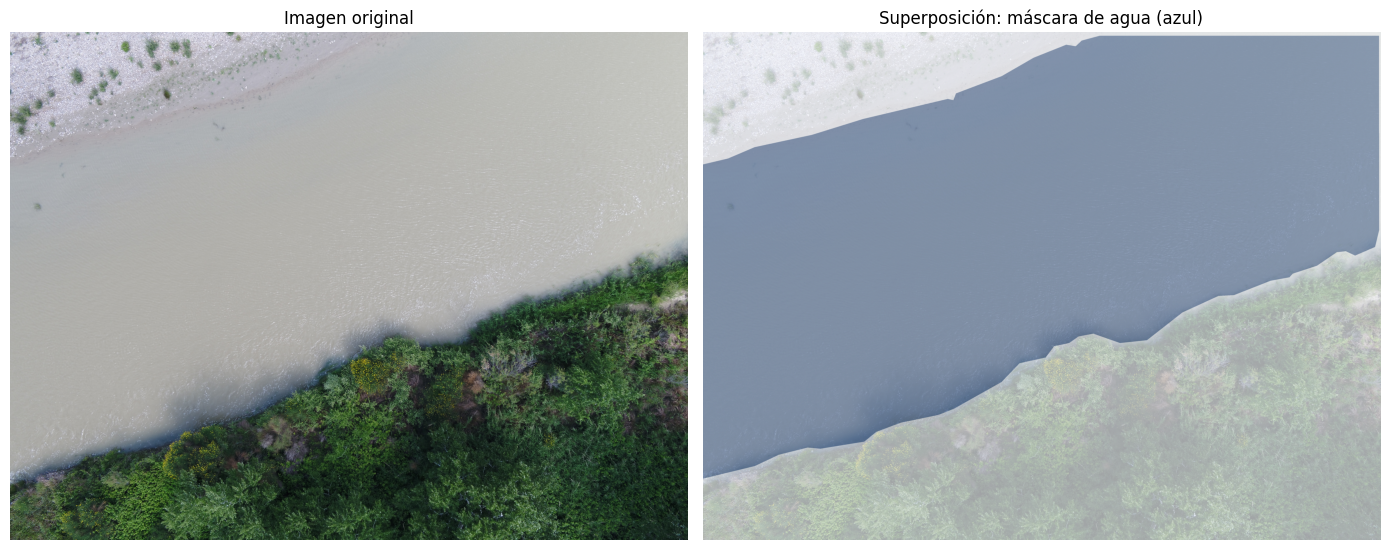

NameError: name 'imagen_rgb' is not defined

In [70]:
def visualizar_mascara_agua(ruta_imagen, ruta_mascara_json, foto_origen):
    """
    Visualiza la máscara de agua superpuesta en la imagen original.
    """
    from water_masc1 import cargar_mascara_desde_labeling  # Ajusta según tu import
    
    imagen = cv2.imread(str(ruta_imagen))
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    h, w = imagen_rgb.shape[:2]
    
    # Carga máscara (igual que en entrenamiento)
    mascara_agua = cargar_mascara_desde_labeling(str(ruta_mascara_json), h, w)
    
    # Visualiza
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    axes[0].imshow(imagen_rgb)
    axes[0].set_title('Imagen original')
    axes[0].axis('off')
    
    axes[1].imshow(imagen_rgb, alpha=0.6)
    axes[1].imshow(mascara_agua, cmap='Blues', alpha=0.4)
    axes[1].set_title('Superposición: máscara de agua (azul)')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()


# === USO ===
INDICE_FOTO = 12

df_index = pd.read_csv(BASE_PATH / 'data' / 'metadata' / 'river_water_index.csv')

foto_a_visualizar = df_anomalias['foto_origen'].unique()[INDICE_FOTO]
row_imagen = df_index[df_index['filepath'].str.contains(foto_a_visualizar)].iloc[0]
ruta_imagen = BASE_PATH / row_imagen['filepath']
ruta_mascara = BASE_PATH / row_imagen['segmentation_mask_path']

visualizar_mascara_agua(
    ruta_imagen=str(ruta_imagen),
    ruta_mascara_json=str(ruta_mascara),
    foto_origen=foto_a_visualizar
)

# Mira los valores de centroide
foto_test = df_anomalias['foto_origen'].iloc[0]
df_test = df_superpixeles[df_superpixeles['foto_origen'] == foto_test]
anomalias_test = df_test[df_test['anomalia'] == -1]

print(f"Resolución imagen: {imagen_rgb.shape}")
print(f"\nCentroides de anomalías (primeros 5):")
print(anomalias_test[['centroid_x', 'centroid_y']].head())
print(f"\nMax X: {anomalias_test['centroid_x'].max()}")
print(f"Max Y: {anomalias_test['centroid_y'].max()}")